
## (o_hmt_rt) model for PDF shaping (n samples)

This uses the new object oriented class for PDF shaping.

* o_hmt_rt ...... i_h2i_rate, i_h2_temp, i_ng_rate, i_ng_temp, i_pci_rate, i_wpi_rate, i_sgi_rate, i_sgi_COH2ratio, i_sgi_ReProRatio, i_o2_volfract, i_hbtemp, i_wind_rt, i_blast_H2O, i_bdn_H2O

## Web applicationi inputs and 1 outputs

Run interactively on the web at: https://rcalix1.github.io/ProbabilityDensityFunctionsFromNeuralNets/experiments/2023/july2023/XGBoost/deployment/tuyere/




## Inputs


(2, 'i_h2i_rate').........i_h2i_rate

(3, 'i_pci_rate').........i_pci_rate

(4, 'i_wpi_rate').........i_wpi_rate

(5, 'i_ngi_rate').........i_ng_rate

(6, 'i_o2_volfract').......i_o2_volfract

(7, 'i_ng_temp')...........i_ng_temp

(8, 'i_h2_temp')...........i_h2_temp

(9, 'i_hbtemp')............i_hbtemp

(10, 'i_wind_rt')..........i_wind_rt

(11, 'i_blastH2O').........i_blast_H2O

(12, 'i_BdnH2O')............i_bdn_H2O

(13, 'i_sgi_rate').........i_sgi_rate

(15, 'i_sgi_COH2ratio').....i_sgi_COH2ratio

(16, 'i_sgi_ReProRatio')....i_sgi_ReProRatio


  

## Outputs


(29, 'o_hmt')





## Installs


In [1]:

## !pip install xgboost
## !pip install onnxmltools
## !pip install onnxruntime



## Imports


In [2]:

import torch
import numpy as np
import pandas as pd
import sklearn
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import math
import seaborn as sns
import random
import functorch


import torch.optim as optim


from numpy.random import normal
from scipy.stats import norm
import scipy.stats as stats
from numpy import hstack
from numpy import vstack
from numpy import exp
from sklearn.neighbors import KernelDensity

##from typing import Optional

from torch import Tensor


from torch.utils.data import TensorDataset, DataLoader

from mlxtend.plotting import heatmap

## coefficient of determination (R**2)
from sklearn.metrics import r2_score

np.set_printoptions(suppress=True)
torch.set_printoptions(sci_mode=False)




In [4]:

import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor, DMatrix, train as train_xgb
from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import onnxmltools
from onnxmltools.convert.xgboost.operator_converters.XGBoost import (
    convert_xgboost)
from onnxmltools.convert import convert_xgboost as convert_xgboost_booster


from zipfile import ZipFile
from skl2onnx.common.data_types import FloatTensorType
from skl2onnx import convert_sklearn, to_onnx, update_registered_converter
from skl2onnx.common.shape_calculator import (
    calculate_linear_classifier_output_shapes,
    calculate_linear_regressor_output_shapes)


# Import the ONNX runtime environment
import onnxruntime as rt



In [5]:

import PDFshapingUtils as PDF_tk



## Instantiate PDF shaping and regression class


In [6]:

PDFshapingOBJ = PDF_tk.PDFshapingUtils()



## Initialize parameters


In [7]:

PDFshapingOBJ.N_error_range = 5         ## 20
PDFshapingOBJ.mean_impulse  = 0.0       ## -7.0      ## 0.0
PDFshapingOBJ.std_impulse   = 0.001     ## 1.0
PDFshapingOBJ.kde_std       = 0.5       ## 0.1       ## 0.5      ## 3.0  ## smaller is better approximation?
PDFshapingOBJ.bandwidth     = 0.2       ## 0.2->more jagged, 2.0->more smooth


In [8]:

PDFshapingOBJ.initializeImpulseGaussian()



## Run checks


In [9]:

## print(PDFshapingOBJ.x_range_impulse_func )
## print(PDFshapingOBJ.impulse_func_vector_vals )
## print(PDFshapingOBJ.quadratic_weights)
print(PDFshapingOBJ.x_range_impulse_func.shape )
print(PDFshapingOBJ.impulse_func_vector_vals.shape )
print(PDFshapingOBJ.quadratic_weights.shape)
 
print( sum(PDFshapingOBJ.impulse_func_vector_vals) )      ## should add up to 100 (i.e. 1.0 prob density)


torch.Size([1000])
torch.Size([1000])
torch.Size([1000])
tensor(100.0000)


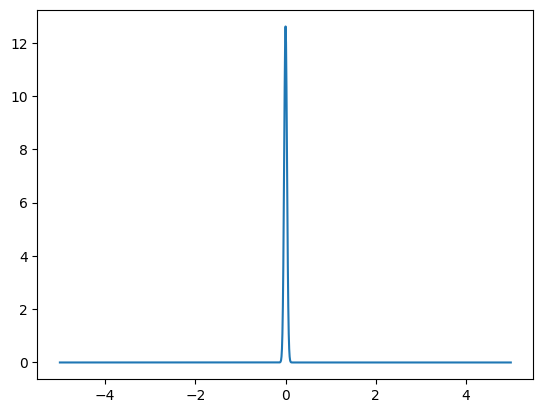

In [10]:

plt.plot(PDFshapingOBJ.x_range_impulse_func, PDFshapingOBJ.impulse_func_vector_vals)
plt.show()



## RUN KDE test


In [11]:

## PDFshapingOBJ.test_torchKDE_with_fake_data()



## Load Data


In [12]:

PDFshapingOBJ.read_csv_file_with_pandas('CFD.15.2025.csv')


In [13]:

PDFshapingOBJ.CFD_raw_data


,index,case name,i_h2i_rate,i_pci_rate,i_wpi_rate,i_ngi_rate,i_o2_volfract,i_ng_temp,i_h2_temp,i_hbtemp,...,o_h2o_sollos,o_feo_sollos,o_hm_rt,o_mw_rt,o_wf_rt,o_hm_h2share,o_mw_h2share,o_wf_h2share,o_prod_rt,o_fta
0,1,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,0,1200,...,18.5,52.6,122.0,265.0,684.0,27.9,23.4,60.6,4060.0,1850.0
1,2,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,0,1200,...,18.7,45.4,145.0,312.0,821.0,24.2,22.6,57.4,4790.0,1890.0
2,3,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,0,1480,...,17.9,30.2,160.0,345.0,930.0,40.7,17.0,57.6,5290.0,1910.0
3,4,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,0,1480,...,18.2,39.1,191.0,413.0,1140.0,25.8,19.1,53.2,6330.0,2040.0
4,5,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,0,1600,...,19.6,29.6,166.0,360.0,977.0,40.3,16.5,58.8,5510.0,1980.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4183,4184,H2-50_PCI-0_WPI-0_NG-0_O2-30_NGT-0_H2T-600_HBT...,50,0,0,0,30,0,600,1600,...,18.3,40.2,336.0,726.0,2100.0,30.8,25.3,58.0,11100.0,2630.0
4184,4185,H2-50_PCI-0_WPI-0_NG-0_O2-30_NGT-300_H2T-0_HBT...,50,0,0,0,30,300,0,1200,...,19.4,39.9,295.0,638.0,1790.0,32.9,28.1,57.7,9790.0,2200.0
4185,4186,H2-50_PCI-0_WPI-0_NG-0_O2-30_NGT-300_H2T-0_HBT...,50,0,0,0,30,300,0,1448,...,18.1,42.0,295.0,639.0,1800.0,33.4,28.3,58.4,9780.0,2360.0
4186,4187,H2-50_PCI-0_WPI-0_NG-0_O2-30_NGT-300_H2T-0_HBT...,50,0,0,0,30,300,0,1448,...,19.6,39.6,295.0,638.0,1800.0,33.3,28.2,58.3,9790.0,2310.0


In [14]:

PDFshapingOBJ.print_headers_list()


['index', 'case name', 'i_h2i_rate', 'i_pci_rate', 'i_wpi_rate', 'i_ngi_rate', 'i_o2_volfract', 'i_ng_temp', 'i_h2_temp', 'i_hbtemp', 'i_wind_rt', 'i_blastH2O', 'i_BdnH2O', 'i_sgi_rate', 'i_sgtemp', 'i_sgi_COH2ratio', 'i_sgi_ReProRatio', 'o_tuy_velo', 'o_tuy_temp', 'o_burn', 'o_delp', 'o_co_vf', 'o_co2_vf', 'o_h2_vf', 'o_n2_vf', 'o_co_util', 'o_h2_util', 'o_tgt', 'o_coke_rt', 'o_hmt', 'o_co2_sollos', 'o_h2o_sollos', 'o_feo_sollos', 'o_hm_rt', 'o_mw_rt', 'o_wf_rt', 'o_hm_h2share', 'o_mw_h2share', 'o_wf_h2share', 'o_prod_rt', 'o_fta']
41
(0, 'index')
(1, 'case name')
(2, 'i_h2i_rate')
(3, 'i_pci_rate')
(4, 'i_wpi_rate')
(5, 'i_ngi_rate')
(6, 'i_o2_volfract')
(7, 'i_ng_temp')
(8, 'i_h2_temp')
(9, 'i_hbtemp')
(10, 'i_wind_rt')
(11, 'i_blastH2O')
(12, 'i_BdnH2O')
(13, 'i_sgi_rate')
(14, 'i_sgtemp')
(15, 'i_sgi_COH2ratio')
(16, 'i_sgi_ReProRatio')
(17, 'o_tuy_velo')
(18, 'o_tuy_temp')
(19, 'o_burn')
(20, 'o_delp')
(21, 'o_co_vf')
(22, 'o_co2_vf')
(23, 'o_h2_vf')
(24, 'o_n2_vf')
(25, 'o_co_ut

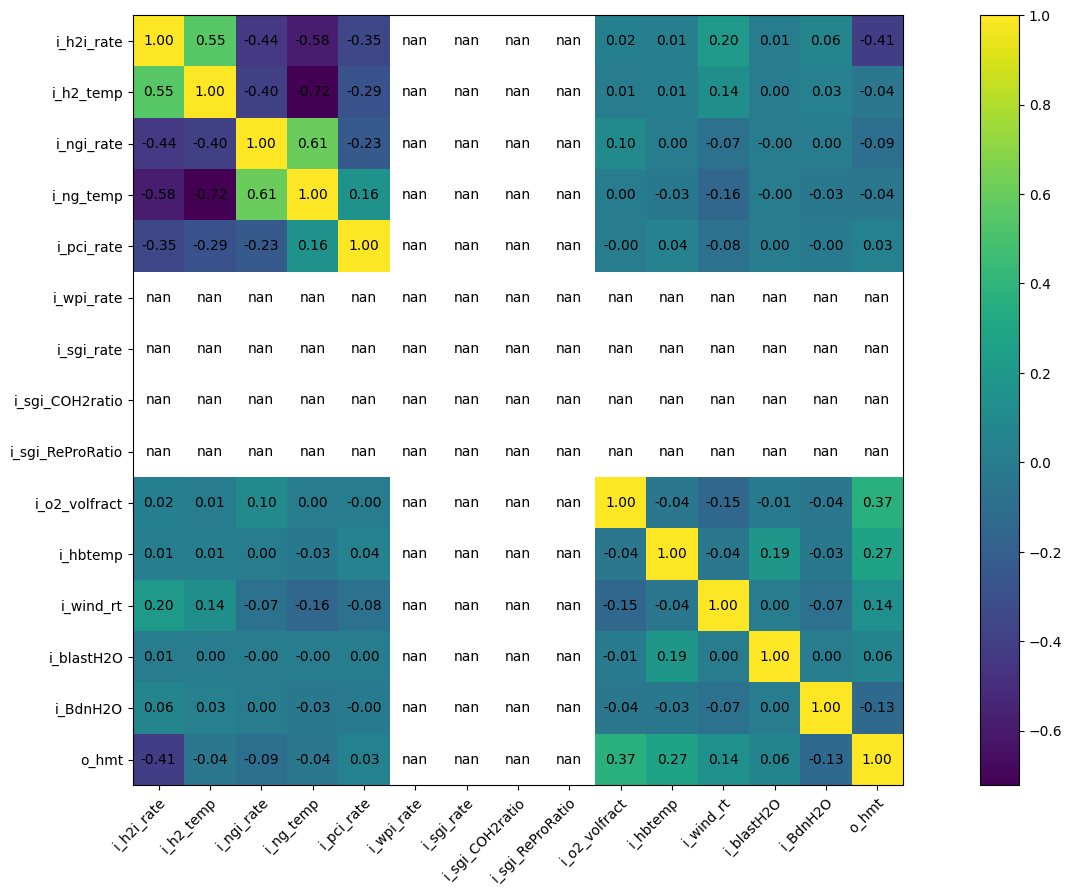

In [28]:

PDFshapingOBJ.list_of_selected_column_names = ['i_h2i_rate','i_h2_temp','i_ngi_rate','i_ng_temp','i_pci_rate',
                    'i_wpi_rate','i_sgi_rate','i_sgi_COH2ratio','i_sgi_ReProRatio','i_o2_volfract',
                    'i_hbtemp','i_wind_rt','i_blastH2O','i_BdnH2O','o_hmt']

ONNX_name = 'o_hmt'


PDFshapingOBJ.print_correlation_coefficients()


In [29]:

PDFshapingOBJ.convert_pd_data_to_numpy()


[[1
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-1_SGI-0_SGT-0_SGC-0'
  0 ... 60.6 4060.0 1850.0]
 [2
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-230_MHB-5.7_BM-1_SGI-0_SGT-0_SGC-0'
  0 ... 57.4 4790.0 1890.0]
 [3
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1480_WR-160_MHB-5.7_BM-1_SGI-0_SGT-0_SGC-0'
  0 ... 57.6 5290.0 1910.0]
 ...
 [4186
  'H2-50_PCI-0_WPI-0_NG-0_O2-30_NGT-300_H2T-0_HBT-1448_WR-195_MHB-0_BM-7_SGI-0_SGT-0_SGC-0'
  50 ... 58.4 9780.0 2360.0]
 [4187
  'H2-50_PCI-0_WPI-0_NG-0_O2-30_NGT-300_H2T-0_HBT-1448_WR-195_MHB-11.4_BM-7_SGI-0_SGT-0_SGC-0'
  50 ... 58.3 9790.0 2310.0]
 [4188
  'H2-50_PCI-0_WPI-0_NG-0_O2-30_NGT-300_H2T-0_HBT-1600_WR-195_MHB-11.4_BM-7_SGI-0_SGT-0_SGC-0'
  50 ... 57.9 9780.0 2400.0]]
(4188, 41)



## Select inputs and outputs


In [30]:

PDFshapingOBJ.gen_X_y_for_selected_indeces(  
                   inputs = [ 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16 ] , 
                   outputs= [ 29 ]   
)







14
1


In [31]:

print(PDFshapingOBJ.X.shape)
print(PDFshapingOBJ.y.shape)


(4188, 14)
(4188, 1)


In [32]:

PDFshapingOBJ.random_seed = int( random.random() * 100  )         ## defautl is 42


In [33]:

PDFshapingOBJ.split_np_data_train_test(selected_test_size=0.2)


(3350, 14)
(838, 14)
(3350, 1)
(838, 1)


In [34]:

PDFshapingOBJ.convert_dataset_from_np_to_torch()


In [35]:

PDFshapingOBJ.standardize_X_scales()
PDFshapingOBJ.standardize_y_scales()


In [36]:

PDFshapingOBJ.gen_Dataloader_train()

PDFshapingOBJ.train_dl



## NN architectures


In [37]:

#######################################################
## Linear Regression

class LinRegNet_SIO(nn.Module):
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations):
        super().__init__()
        
        self.x_means      = x_means
        self.x_deviations = x_deviations
        self.y_means      = y_means
        self.y_deviations = y_deviations
        
        self.linear1 = nn.Linear(14, 1) 
        
        ## nn.init.xavier_uniform_(self.linear1.weight)
        ## nn.init.zeros_(self.linear1.bias)

    ## perform inference
    def forward(self, x):
        x = (x - self.x_means) / self.x_deviations
        
        y_scaled = self.linear1(x)
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled

    
#############################################################
## Multi-Layer Perceptron

class MLP_Net_SIO(nn.Module):
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations):
        super().__init__()
        
        self.x_means      = x_means
        self.x_deviations = x_deviations
        self.y_means      = y_means
        self.y_deviations = y_deviations
        
        self.linear1 = nn.Linear(14, 10)
        self.act1    = nn.Sigmoid()                       ## Tanh() 
        self.linear2 = nn.Linear(10, 1)
        self.dropout = nn.Dropout(0.25)
        
        ## nn.init.xavier_uniform_(self.linear1.weight)
        ## nn.init.zeros_(self.linear1.bias)
        
        ## nn.init.xavier_uniform_(self.linear2.weight)
        ## nn.init.zeros_(self.linear2.bias)
    
    ## perform inference
    def forward(self, x):
        x = (x - self.x_means) / self.x_deviations
        x = self.linear1(x)
        x = self.act1(x)
        x = self.dropout(x)
        
        y_scaled = self.linear2(x)
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled
    

#############################################################
## Deep Learning model with 2 hidden layers


class DL_Net_SIO(nn.Module):
    
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations):
        super().__init__()
        
        self.x_means      = x_means
        self.x_deviations = x_deviations
        self.y_means      = y_means
        self.y_deviations = y_deviations
        
        self.linear1 = nn.Linear(14, 10)
        self.act1    = nn.Sigmoid()                       ## Tanh() 
        self.linear2 = nn.Linear(10, 6)
        self.act2    = nn.Sigmoid() 
        self.linear3 = nn.Linear(6, 1)
        self.dropout = nn.Dropout(0.25)
        
        ## nn.init.xavier_uniform_(self.linear1.weight)
        ## nn.init.zeros_(self.linear1.bias)
        
        ## nn.init.xavier_uniform_(self.linear2.weight)
        ## nn.init.zeros_(self.linear2.bias)
        
        ## nn.init.xavier_uniform_(self.linear3.weight)
        ## nn.init.zeros_(self.linear3.bias)
    
    ## perform inference
    def forward(self, x):
        
        x = (x - self.x_means) / self.x_deviations
        x = self.linear1(x)
        x = self.act1(x)
        x = self.dropout(x)
        x = self.linear2(x)
        x = self.act2(x)
        x = self.dropout(x)
        
        y_scaled = self.linear3(x)
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled


In [38]:

#############################################################
##   F1      plus       F2
## Linear     +      Nonlinear

class F1plusF2_SIO(nn.Module):
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations):
        super().__init__()
        
        self.x_means      = x_means
        self.x_deviations = x_deviations
        self.y_means      = y_means
        self.y_deviations = y_deviations
        
        ## F1
        self.f1_linear1 = nn.Linear(14, 1)       
        
        ## F2
        self.f2_linear1 = nn.Linear(14, 10)
        self.f2_act1    = nn.Sigmoid()                    ## Tanh()                       
        self.f2_linear2 = nn.Linear(10, 1)       
        self.f2_dropout = nn.Dropout(0.25)
        
        
    ## perform inference
    def forward(self, x):
        x = (x - self.x_means) / self.x_deviations
        
        ## F1
        f1 = self.f1_linear1(x)
        
        ## F2
        f2 = self.f2_linear1(x)
        f2 = self.f2_act1(f2)
        f2 = self.f2_dropout(f2)
        f2 = self.f2_linear2(f2)
        
        
        y_scaled   = f1 + f2
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled
    



## Results for g(x) = F1(x) + F2(x) with No PDF shaping

F1 = Linear

F2 = Nonlinear


In [39]:

def fit_y_scaled(num_epochs, model, loss_fn, opt):
    
    PDFshapingOBJ.list_metric = []
    for epoch in range(num_epochs):
        for xb, yb in PDFshapingOBJ.train_dl:
            pred_descaled, pred_scaled = model(xb)
            loss = loss_fn(pred_scaled, yb)
            loss.backward()
            opt.step()
            opt.zero_grad()
        
        if epoch % 200 == 0:
            print(epoch, " loss= ", loss)
            
            
        pred_descaled, pred_scaled = model(PDFshapingOBJ.X_train_tr)
        r2_avg = torch.mean(
            torch.tensor(
                r2_score( pred_scaled.detach().numpy(),  PDFshapingOBJ.y_train_tr_scaled.numpy()   )
            )
        )
        PDFshapingOBJ.list_metric.append(  r2_avg.detach().numpy()  )
            
    PDFshapingOBJ.func_plot_performance()
            
    pred_descaled, pred_scaled = model(PDFshapingOBJ.X_train_tr)
    print('Training loss:', loss_fn(  pred_scaled,           PDFshapingOBJ.y_train_tr_scaled          ))
    print('Training R**2:', r2_score( pred_scaled.detach().numpy(), PDFshapingOBJ.y_train_tr_scaled.numpy()  ))
    


In [40]:

PDFshapingOBJ.the_string           = "No_PDF_shaping"
PDFshapingOBJ.furnace_model_name   = ONNX_name


0  loss=  tensor(0.3583, grad_fn=<MseLossBackward0>)
200  loss=  tensor(0.0086, grad_fn=<MseLossBackward0>)
400  loss=  tensor(0.0185, grad_fn=<MseLossBackward0>)
600  loss=  tensor(0.0280, grad_fn=<MseLossBackward0>)
800  loss=  tensor(0.0083, grad_fn=<MseLossBackward0>)
1000  loss=  tensor(0.0227, grad_fn=<MseLossBackward0>)
1200  loss=  tensor(0.0662, grad_fn=<MseLossBackward0>)
1400  loss=  tensor(0.0322, grad_fn=<MseLossBackward0>)
1600  loss=  tensor(0.0616, grad_fn=<MseLossBackward0>)
1800  loss=  tensor(0.0747, grad_fn=<MseLossBackward0>)


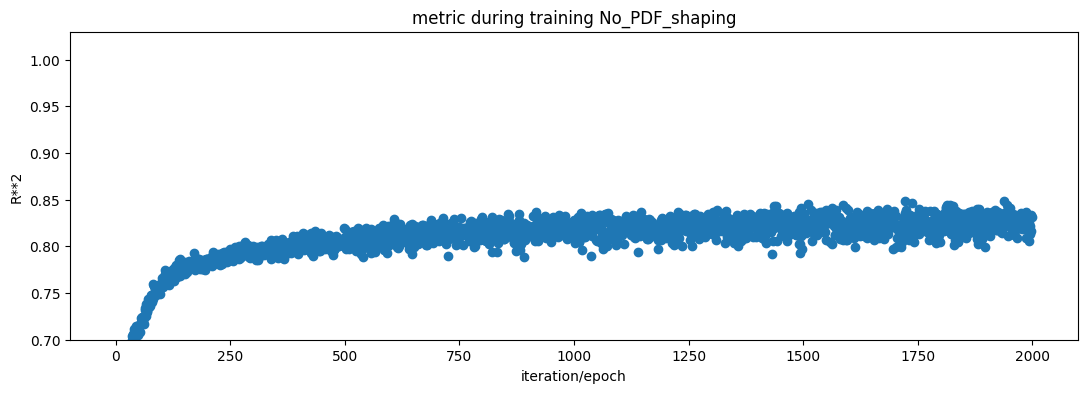

Training loss: tensor(0.1447, grad_fn=<MseLossBackward0>)
Training R**2: 0.8315606162869429
Test loss - scaled: tensor(0.1120, grad_fn=<MseLossBackward0>)
Test loss - descaled: tensor(33665.4492, grad_fn=<MseLossBackward0>)
Testing R**2 - scaled: 0.8604922286293943
Testing R**2 - descaled: 0.8604922347669476
*****
*****
Testing R**2 - Output: 0 o_hmt 0.8604922347669476


In [41]:

model = F1plusF2_SIO(
             PDFshapingOBJ.x_means, 
             PDFshapingOBJ.x_deviations, 
             PDFshapingOBJ.y_means, 
             PDFshapingOBJ.y_deviations
)

opt = torch.optim.Adam(   model.parameters(), lr=PDFshapingOBJ.learning_rate   )
loss_fn = F.mse_loss


fit_y_scaled(PDFshapingOBJ.N_EPOCHS, model, loss_fn, opt)


pred_descaled, pred_scaled = model(PDFshapingOBJ.X_test_tr)
print('Test loss - scaled:',   loss_fn(     pred_scaled,         PDFshapingOBJ.y_test_tr_scaled          ))
print('Test loss - descaled:', loss_fn(     pred_descaled,       PDFshapingOBJ.y_test_tr                 ))
print('Testing R**2 - scaled:', r2_score( pred_scaled.detach().numpy(), PDFshapingOBJ.y_test_tr_scaled.numpy() ))
print('Testing R**2 - descaled:', r2_score( pred_descaled.detach().numpy(), PDFshapingOBJ.y_test_tr.numpy()    ))

PDFshapingOBJ.print_individual_Rsquare(pred_descaled, PDFshapingOBJ.y_test_tr)


In [42]:

list_preds = []
list_reals = []

for i in range(len(PDFshapingOBJ.X_test_tr)):
    print("**************************************************")
    print("preds, real")
    preds_descaled, preds_scaled = model(PDFshapingOBJ.X_test_tr[i])

    np_pred = preds_descaled[0].detach().numpy()              ## [0]
    np_real = PDFshapingOBJ.y_test_tr[i].detach().numpy()

    for j in range(len(np_pred)):
        print((np_pred[j], np_real[j]))
        list_preds.append(np_pred[j])
        list_reals.append(np_real[j])


**************************************************
preds, real
(1416.812, 1370.0)
**************************************************
preds, real
(1227.9105, 1100.0)
**************************************************
preds, real
(1599.5726, 1710.0)
**************************************************
preds, real
(1349.0061, 1250.0)
**************************************************
preds, real
(1740.3175, 1590.0)
**************************************************
preds, real
(975.4186, 782.0)
**************************************************
preds, real
(1631.0712, 1650.0)
**************************************************
preds, real
(1128.8331, 1290.0)
**************************************************
preds, real
(1965.56, 1960.0)
**************************************************
preds, real
(1784.8339, 1870.0)
**************************************************
preds, real
(1492.054, 1430.0)
**************************************************
preds, real
(79.357544, 146.0)
***********

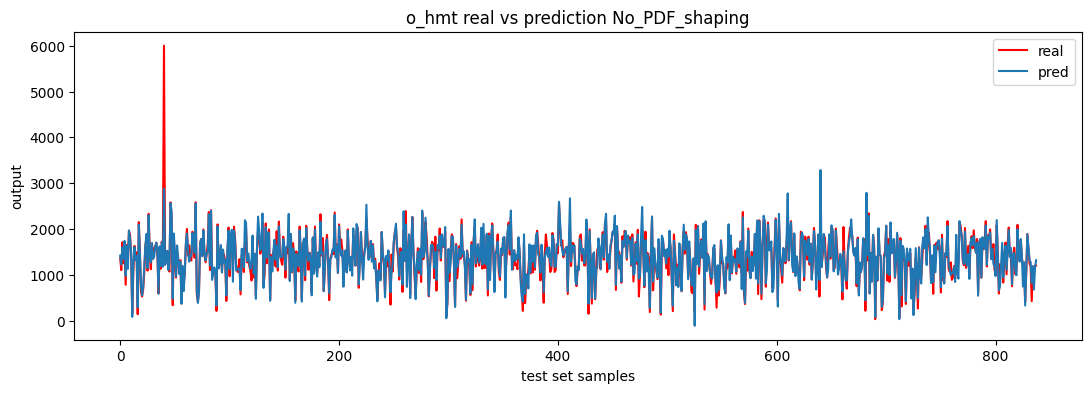

/Users/user/Desktop/CIVS_last_Phase/Forward/2025july/NewDataset/PDFshapingUtils.py:353: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(error, bins=n_bins, color="blue")


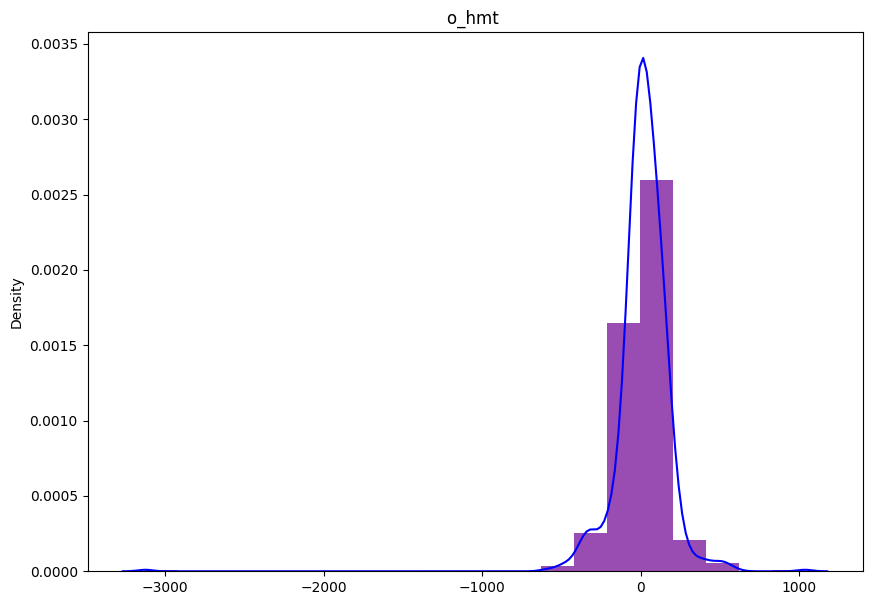

In [43]:

PDFshapingOBJ.plot_preds_vs_reals( list_preds, list_reals )



## Export ONNX model


In [44]:


name_to_use_onnx = "ONNXmodels/F1plusF2NNs_" + ONNX_name + ".onnx"

model.eval()

dummy_input = torch.randn(1, 14)


input_names = ["input1"]
output_names = ["output1", "output2"]

torch.onnx.export(
  model, 
  dummy_input, 
  name_to_use_onnx, 
  verbose=False, 
  input_names  = input_names,
  output_names = output_names
)




## To compare NNs to XGBoost


In [45]:

##      y_pred = regressor.predict(PDFshapingOBJ.X_test )

pred_descaled, pred_scaled = model(PDFshapingOBJ.X_test_tr)


In [46]:

pred_descaled


tensor([[1432.5334],
        [1114.2321],
        [1694.6567],
        [1354.6052],
        [1559.0452],
        [ 912.3303],
        [1626.5569],
        [1163.0302],
        [1891.8831],
        [1889.8110],
        [1479.7976],
        [ 149.4641],
        [1240.4016],
        [1622.7197],
        [1322.0402],
        [1433.9752],
        [ 243.0261],
        [2066.7634],
        [1507.9915],
        [ 789.8817],
        [ 615.4094],
        [ 753.9003],
        [1187.6880],
        [1652.2751],
        [1917.1442],
        [1036.8860],
        [2323.6541],
        [1390.8835],
        [1278.8109],
        [1714.5858],
        [1363.5272],
        [1457.6594],
        [1598.7559],
        [1650.2067],
        [1488.0769],
        [ 595.4905],
        [1610.2028],
        [1189.1805],
        [1701.8488],
        [1196.4679],
        [2745.5000],
        [1219.5300],
        [1312.5236],
        [1523.1458],
        [1148.8142],
        [1285.2997],
        [2507.9827],
        [3183

In [47]:

## r2_score( PDFshapingOBJ.y_test, y_pred )

print('Testing R**2 - scaled:', r2_score( pred_scaled.detach().numpy(), PDFshapingOBJ.y_test_tr_scaled.numpy() ))
print('Testing R**2 - descaled:', r2_score( pred_descaled.detach().numpy(), PDFshapingOBJ.y_test_tr.numpy()    ))


Testing R**2 - scaled: 0.8740649855959403
Testing R**2 - descaled: 0.874064973673738



## Results for g(x) = F1(x) + F2(x) with PDF shaping

F1 = Linear

F2 = Nonlinear


In [50]:

def fit_y_scaled_PDF(num_epochs, num_epochs_pdf, model, loss_fn, opt, kl_loss, scheduler):
    
    PDFshapingOBJ.list_metric = []
      
    for epoch in range(num_epochs):
        for xb, yb in PDFshapingOBJ.train_dl:
            
            pred_descaled, pred_scaled = model(xb)
            loss = loss_fn(pred_scaled, yb)
            opt.zero_grad()
            loss.backward()
            opt.step()
            
            
        if epoch % 200 == 0:
            print(epoch, " loss= ", loss)
        
        pred_descaled, pred_scaled = model(PDFshapingOBJ.X_train_tr)
        r2_avg = torch.mean(torch.tensor(
                r2_score( pred_scaled.detach().numpy(),  PDFshapingOBJ.y_train_tr_scaled.numpy()  )
        ))
        PDFshapingOBJ.list_metric.append(r2_avg.detach().numpy())
        
        
    opt = torch.optim.Adam(   model.parameters(), lr=PDFshapingOBJ.learning_rate_pdfcontrol  )    
        
    for epoch in range(num_epochs_pdf):
        
        pred_descaled, pred_scaled = model(PDFshapingOBJ.X_train_tr)
       
        error =   pred_scaled.float() - PDFshapingOBJ.y_train_tr_scaled.float()          ## 715  x 1
        
        basisFunc = PDFshapingOBJ.train_multiple_kernels_per_output( error )             ## 1000 x 1
        
        p_pred = basisFunc.float() 
        q_real = PDFshapingOBJ.impulse_func_vector_vals.unsqueeze(1).float() 
        
        
        diff = ( p_pred - q_real )**2              ## 1000 x 1
        diff = diff * PDFshapingOBJ.quadratic_weights.unsqueeze(1)      
          
        
        loss = torch.mean( diff  ) 
        

        ## loss_diff = loss_fn(p_pred, q_real)
        ## input_kl  = F.log_softmax(p_pred, dim=0) # F.log_softmax(p_kl)
        ## target_kl = F.softmax(    q_real, dim=0) # F.softmax(q_kl)
        ## loss =  loss_diff   ## kl_loss(input_kl, target_kl)  ##   +  torch.std(p_pred)
        
        
        opt.zero_grad()
        loss.backward()
        opt.step()
        
      
        
        ## PDFshapingOBJ.updateImpulseGaussian_with_new_standard_deviation(decay_impulse_std )
        

        ## print(epoch, " loss= ", loss)
        if epoch % 5000 == 0:
            print(epoch, " loss= ", loss)
            print(PDFshapingOBJ.impulse_func_vector_vals.shape )
            print(PDFshapingOBJ.quadratic_weights.shape)
            print(error.shape)
            print(basisFunc.shape)
            ##### PDFshapingOBJ.print_errors_kdes(  error, basisFunc )
            print(PDFshapingOBJ.impulse_func_vector_vals.shape)
            print('Epoch-{0} lr: {1}'.format(epoch, opt.param_groups[0]['lr']))
      

        r2_avg = torch.mean(torch.tensor(
                 r2_score( pred_scaled.detach().numpy(),  PDFshapingOBJ.y_train_tr_scaled.numpy()  )
        ))
        PDFshapingOBJ.list_metric.append(  r2_avg.detach().numpy()  )
        
        
            
    PDFshapingOBJ.func_plot_performance()
            
    pred_descaled, pred_scaled = model(PDFshapingOBJ.X_train_tr)
    print('Training loss:', loss_fn(  pred_scaled,       PDFshapingOBJ.y_train_tr_scaled          ))
    print('Training R**2:', r2_score( pred_scaled.detach().numpy(), PDFshapingOBJ.y_train_tr_scaled.numpy() ))
    


In [51]:

PDFshapingOBJ.the_string           = "With_PDF_shaping"
PDFshapingOBJ.furnace_model_name   = ONNX_name

PDFshapingOBJ.learning_rate_pdfcontrol  = 0.001       ## 0.001
PDFshapingOBJ.N_EPOCHS_PDF              = 30000
PDFshapingOBJ.N_EPOCHS                  = 0

decay_impulse_std                       = PDFshapingOBJ.std_impulse / PDFshapingOBJ.N_EPOCHS_PDF 


10000
0  loss=  tensor(0.0220, grad_fn=<MeanBackward0>)
torch.Size([1000])
torch.Size([1000])
torch.Size([3350, 1])
torch.Size([1000, 1])
torch.Size([1000])
Epoch-0 lr: 0.001
5000  loss=  tensor(0.0023, grad_fn=<MeanBackward0>)
torch.Size([1000])
torch.Size([1000])
torch.Size([3350, 1])
torch.Size([1000, 1])
torch.Size([1000])
Epoch-5000 lr: 0.001
10000  loss=  tensor(0.0020, grad_fn=<MeanBackward0>)
torch.Size([1000])
torch.Size([1000])
torch.Size([3350, 1])
torch.Size([1000, 1])
torch.Size([1000])
Epoch-10000 lr: 0.001
15000  loss=  tensor(0.0020, grad_fn=<MeanBackward0>)
torch.Size([1000])
torch.Size([1000])
torch.Size([3350, 1])
torch.Size([1000, 1])
torch.Size([1000])
Epoch-15000 lr: 0.001
20000  loss=  tensor(0.0019, grad_fn=<MeanBackward0>)
torch.Size([1000])
torch.Size([1000])
torch.Size([3350, 1])
torch.Size([1000, 1])
torch.Size([1000])
Epoch-20000 lr: 0.001
25000  loss=  tensor(0.0019, grad_fn=<MeanBackward0>)
torch.Size([1000])
torch.Size([1000])
torch.Size([3350, 1])
torch

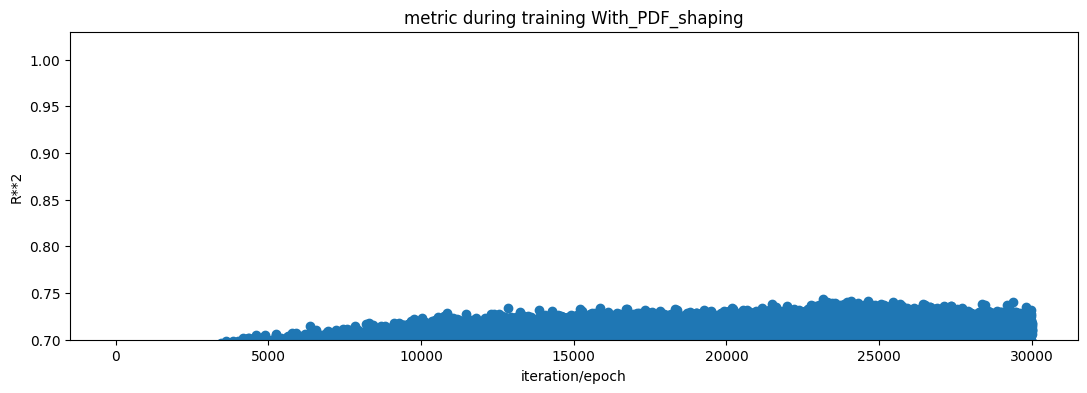

Training loss: tensor(0.2427, grad_fn=<MseLossBackward0>)
Training R**2: 0.7175146159449758
Test loss - scaled: tensor(0.1602, grad_fn=<MseLossBackward0>)
Test loss - descaled: tensor(48146.4688, grad_fn=<MseLossBackward0>)
Testing R**2 - scaled: 0.7911269745522072
Testing R**2 - descaled: 0.7911269785991268
*****
*****
Testing R**2 - Output: 0 o_hmt 0.7911269785991268


In [52]:

model = F1plusF2_SIO(
             PDFshapingOBJ.x_means, 
             PDFshapingOBJ.x_deviations, 
             PDFshapingOBJ.y_means, 
             PDFshapingOBJ.y_deviations
)



opt         = torch.optim.Adam(   model.parameters(), lr=PDFshapingOBJ.learning_rate_pdfcontrol    )


step_size_scheduler = int(PDFshapingOBJ.N_EPOCHS_PDF / 3)
print(step_size_scheduler)
                          
scheduler   = torch.optim.lr_scheduler.StepLR(opt, step_size=1000, gamma=0.1)



loss_fn      = F.mse_loss
kl_loss      = nn.KLDivLoss(reduction="batchmean")
loss_softmax = F.binary_cross_entropy


fit_y_scaled_PDF(PDFshapingOBJ.N_EPOCHS, PDFshapingOBJ.N_EPOCHS_PDF, model, loss_fn, opt, kl_loss, scheduler)

pred_descaled, pred_scaled = model(PDFshapingOBJ.X_test_tr)
print('Test loss - scaled:',   loss_fn(     pred_scaled,       PDFshapingOBJ.y_test_tr_scaled          ))
print('Test loss - descaled:', loss_fn(     pred_descaled,     PDFshapingOBJ.y_test_tr                 ))
print('Testing R**2 - scaled:',   r2_score( pred_scaled.detach().numpy(),PDFshapingOBJ.y_test_tr_scaled.numpy() ))
print('Testing R**2 - descaled:', r2_score( pred_descaled.detach().numpy(), PDFshapingOBJ.y_test_tr.numpy()   ))


PDFshapingOBJ.print_individual_Rsquare(pred_descaled, PDFshapingOBJ.y_test_tr)


In [53]:

list_preds = []
list_reals = []

for i in range(len(PDFshapingOBJ.X_test_tr)):
    print("**************************************************")
    print("preds, real")
    preds_descaled, preds_scaled = model(PDFshapingOBJ.X_test_tr[i])

    np_pred = preds_descaled[0].detach().numpy()              ## [0]
    np_real = PDFshapingOBJ.y_test_tr[i].detach().numpy()

    for j in range(len(np_pred)):
        print((np_pred[j], np_real[j]))
        list_preds.append(np_pred[j])
        list_reals.append(np_real[j])


**************************************************
preds, real
(1400.049, 1370.0)
**************************************************
preds, real
(1185.6703, 1100.0)
**************************************************
preds, real
(1297.3231, 1710.0)
**************************************************
preds, real
(1239.9607, 1250.0)
**************************************************
preds, real
(1605.4956, 1590.0)
**************************************************
preds, real
(749.35004, 782.0)
**************************************************
preds, real
(1677.2593, 1650.0)
**************************************************
preds, real
(1190.7373, 1290.0)
**************************************************
preds, real
(1899.8854, 1960.0)
**************************************************
preds, real
(1532.0548, 1870.0)
**************************************************
preds, real
(1401.7844, 1430.0)
**************************************************
preds, real
(140.55017, 146.0)
*******

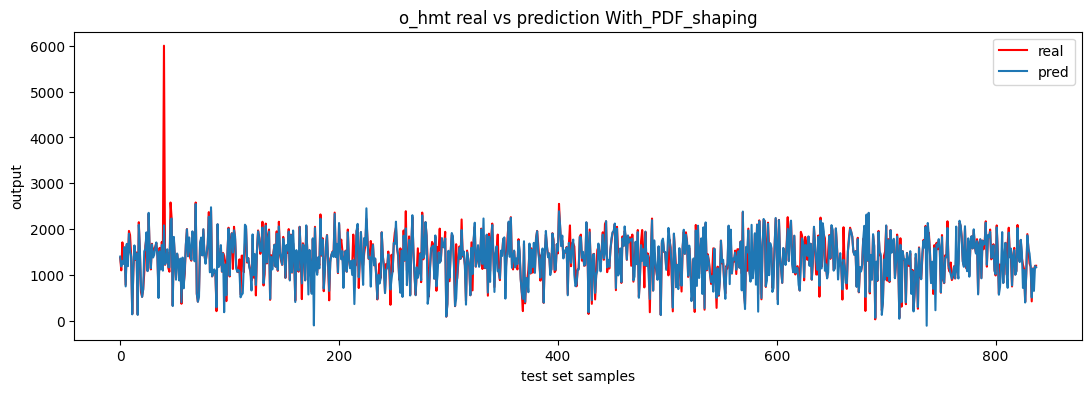

/Users/user/Desktop/CIVS_last_Phase/Forward/2025july/NewDataset/PDFshapingUtils.py:353: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(error, bins=n_bins, color="blue")


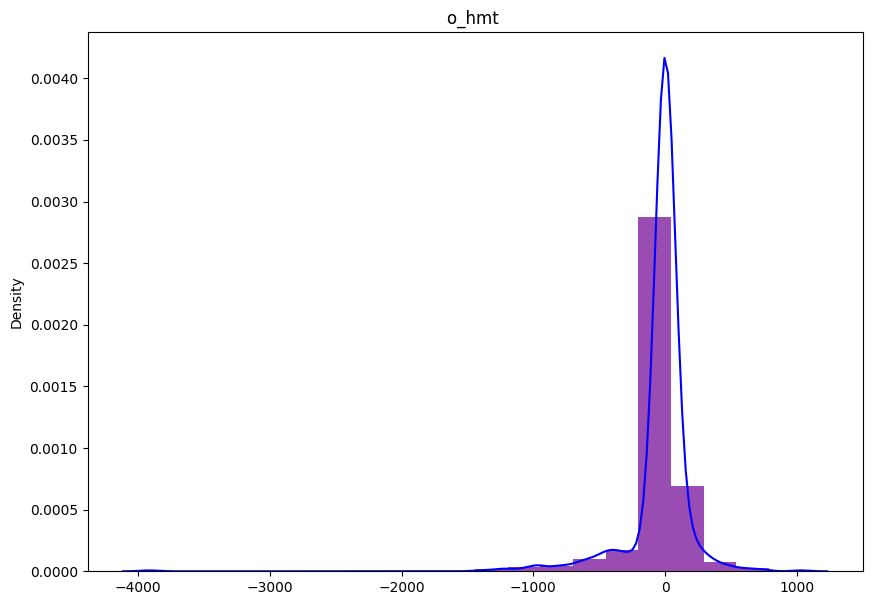

In [54]:

PDFshapingOBJ.plot_preds_vs_reals( list_preds, list_reals )



## To compare to NNs to XGBoost


In [55]:

##      y_pred = regressor.predict(PDFshapingOBJ.X_test )

pred_descaled, pred_scaled = model(PDFshapingOBJ.X_test_tr)


In [56]:

## y_pred

pred_descaled


tensor([[  1517.2373],
        [  1154.8593],
        [  1673.5914],
        [  1352.8676],
        [  1062.3978],
        [   842.7789],
        [  1637.4481],
        [  1442.4619],
        [  2000.1791],
        [  1873.4747],
        [  1426.0000],
        [   143.4258],
        [  1118.1619],
        [  1639.3026],
        [  1339.7106],
        [  1486.0515],
        [   111.4030],
        [  2125.2019],
        [  1526.5981],
        [   953.7438],
        [   559.5540],
        [   683.2407],
        [  1520.5154],
        [  1657.4265],
        [  1914.7765],
        [  1082.8422],
        [  2311.1094],
        [  1433.7290],
        [  1145.8907],
        [  1666.5408],
        [  1386.5243],
        [  1598.9233],
        [  1599.5220],
        [  1786.2468],
        [  1420.4906],
        [   475.7914],
        [  1521.0325],
        [  1091.6492],
        [  1656.4595],
        [  1108.8707],
        [  2130.4814],
        [  1239.9110],
        [  1304.6863],
        [  

In [57]:

## r2_score( PDFshapingOBJ.y_test, y_pred )

print('Testing R**2 - scaled:', r2_score( pred_scaled.detach().numpy(), PDFshapingOBJ.y_test_tr_scaled.numpy() ))
print('Testing R**2 - descaled:', r2_score( pred_descaled.detach().numpy(), PDFshapingOBJ.y_test_tr.numpy()    ))


Testing R**2 - scaled: 0.7711311860618939
Testing R**2 - descaled: 0.7711311921139672



## Export ONNX model


In [58]:

'''

model.eval()

dummy_input = torch.randn(1, 6)


input_names = ["input1"]
output_names = ["output1", "output2"]

torch.onnx.export(
  model, 
  dummy_input, 
  "ONNXmodels/s894TuyereExitVeloMsPDFshapingRC.onnx", 
  verbose=False, 
  input_names  = input_names,
  output_names = output_names
)

'''


'\n\nmodel.eval()\n\ndummy_input = torch.randn(1, 6)\n\n\ninput_names = ["input1"]\noutput_names = ["output1", "output2"]\n\ntorch.onnx.export(\n  model, \n  dummy_input, \n  "ONNXmodels/s894TuyereExitVeloMsPDFshapingRC.onnx", \n  verbose=False, \n  input_names  = input_names,\n  output_names = output_names\n)\n\n'


## XGBoost


In [59]:

regressor = xgb.XGBRegressor(
    n_estimators=100,
    reg_lambda=1,
    gamma=0,
    max_depth=3
)


In [60]:

regressor.fit(PDFshapingOBJ.X_train, PDFshapingOBJ.y_train)


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
             importance_type=None, interaction_constraints='',
             learning_rate=0.300000012, max_bin=256, max_cat_to_onehot=4,
             max_delta_step=0, max_depth=3, max_leaves=0, min_child_weight=1,
             missing=nan, monotone_constraints='()', n_estimators=100, n_jobs=0,
             num_parallel_tree=1, predictor='auto', random_state=0, reg_alpha=0,
             reg_lambda=1, ...)

In [61]:

print( len(PDFshapingOBJ.X_train  ))
print( len(PDFshapingOBJ.y_train  ))
  


3350
3350


In [62]:

## columns_thing = ['i_h2_inj_kg_thm', 'i_pul_coal_inj_kg_thm', 'i_nat_gas_inj_kg_thm', 'i_nat_gas_t_k', 
##                  'i_o2_vol_perce', 'i_hot_blast_temp_k', ]



## pd.DataFrame(regressor.feature_importances_.reshape(1, -1), columns=columns_thing)


In [63]:

y_pred = regressor.predict(PDFshapingOBJ.X_test )


In [64]:

y_pred


array([1424.5205  , 1163.0502  , 1674.7238  , 1312.4097  , 1631.1227  ,
        937.497   , 1619.3687  , 1281.1016  , 1887.4967  , 1877.0571  ,
       1513.4135  ,  153.38083 , 1010.37317 , 1655.5195  , 1392.8574  ,
       1501.4811  ,  194.61885 , 2077.9292  , 1508.7192  ,  490.12814 ,
        454.16382 ,  749.3994  ,  976.08936 , 1552.4799  , 1839.9381  ,
       1096.761   , 2311.2524  , 1437.3241  , 1155.6881  , 1684.2131  ,
       1382.601   , 1560.4773  , 1648.0032  , 1678.7761  , 1489.51    ,
        426.49265 , 1596.6581  , 1231.6328  , 1741.9741  , 1507.1638  ,
       3310.505   , 1222.9962  , 1263.103   , 1509.9291  , 1162.8523  ,
       1045.8047  , 2609.4885  , 2737.2153  ,  495.91132 , 2448.1685  ,
       1253.5051  ,  882.47595 , 2016.1168  , 1272.561   , 1185.0757  ,
       1314.8699  ,  420.94662 ,  998.5537  ,  819.8392  , 1013.49475 ,
       1673.2357  , 1919.4204  , 1457.8815  , 1426.7174  , 1591.4341  ,
       1297.6654  , 1982.1049  , 1791.8503  , 1432.4618  , 2487.

In [65]:

mean_squared_error(PDFshapingOBJ.y_test , y_pred)


20762.97

In [66]:

r2_score( PDFshapingOBJ.y_test, y_pred )


0.9178586426444354

In [67]:

len(y_pred) 


838

In [68]:

list_preds = []
list_reals = []

print( "preds, real"   )
  
for j in range(   len(y_pred)    ):
    print(   y_pred[j], PDFshapingOBJ.y_test[j][0]   )
    
    list_preds.append(   y_pred[j]   )
    list_reals.append(  PDFshapingOBJ.y_test[j][0]   )


preds, real
1424.5205 1370.0
1163.0502 1100.0
1674.7238 1710.0
1312.4097 1250.0
1631.1227 1590.0
937.497 782.0
1619.3687 1650.0
1281.1016 1290.0
1887.4967 1960.0
1877.0571 1870.0
1513.4135 1430.0
153.38083 146.0
1010.37317 1070.0
1655.5195 1630.0
1392.8574 1330.0
1501.4811 1490.0
194.61885 138.0
2077.9292 2150.0
1508.7192 1490.0
490.12814 626.0
454.16382 523.0
749.3994 685.0
976.08936 1050.0
1552.4799 1630.0
1839.9381 1810.0
1096.761 1090.0
2311.2524 2330.0
1437.3241 1450.0
1155.6881 1120.0
1684.2131 1680.0
1382.601 1450.0
1560.4773 1570.0
1648.0032 1610.0
1678.7761 1700.0
1489.51 1450.0
426.49265 592.0
1596.6581 1590.0
1231.6328 1130.0
1741.9741 1720.0
1507.1638 1510.0
3310.505 6000.0
1222.9962 1220.0
1263.103 1350.0
1509.9291 1500.0
1162.8523 1150.0
1045.8047 1070.0
2609.4885 2580.0
2737.2153 2240.0
495.91132 334.0
2448.1685 1790.0
1253.5051 1340.0
882.47595 938.0
2016.1168 1460.0
1272.561 1280.0
1185.0757 1250.0
1314.8699 1320.0
420.94662 371.0
998.5537 1140.0
819.8392 800.0
1013.49

In [69]:

len( list_preds )


838

In [70]:

len( list_reals )


838

In [71]:

PDFshapingOBJ.the_string           = "XGBoost"
PDFshapingOBJ.furnace_model_name   = ONNX_name


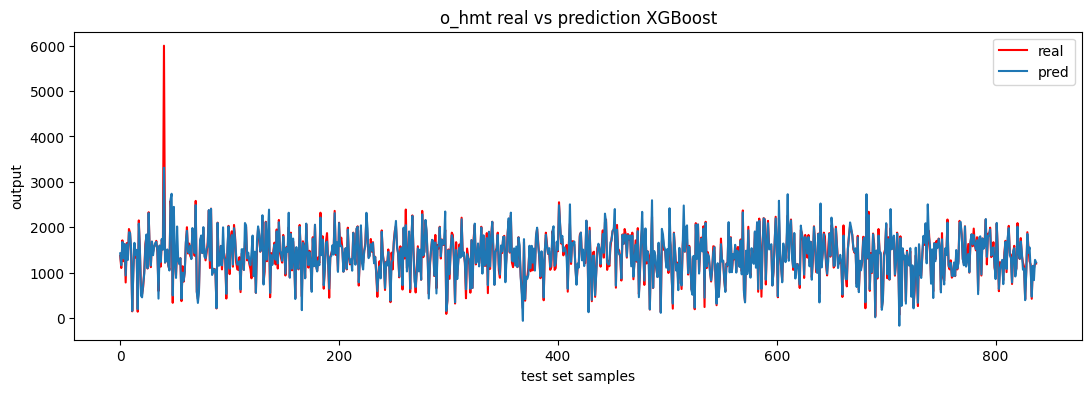

/Users/user/Desktop/CIVS_last_Phase/Forward/2025july/NewDataset/PDFshapingUtils.py:353: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(error, bins=n_bins, color="blue")


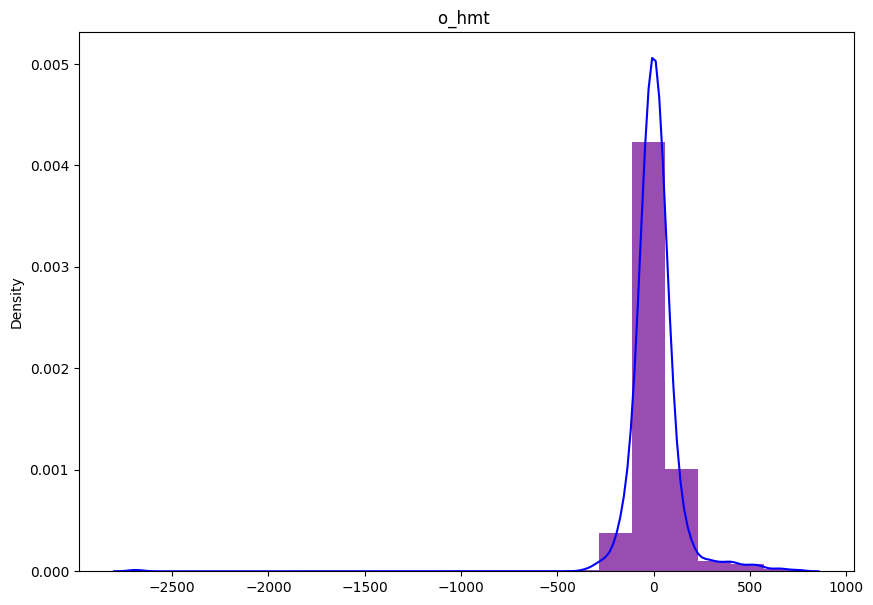

In [72]:

PDFshapingOBJ.plot_preds_vs_reals( list_preds, list_reals )



## ONNX and XGboost


In [73]:

model = xgb.XGBRegressor(
    n_estimators=100,
    reg_lambda=1,
    gamma=0,
    max_depth=3
)


In [74]:


print(model)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, gamma=0, gpu_id=None,
             grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, predictor=None, random_state=None,
             reg_alpha=None, reg_lambda=1, ...)


In [75]:

model.fit( PDFshapingOBJ.X_train, PDFshapingOBJ.y_train)


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
             importance_type=None, interaction_constraints='',
             learning_rate=0.300000012, max_bin=256, max_cat_to_onehot=4,
             max_delta_step=0, max_depth=3, max_leaves=0, min_child_weight=1,
             missing=nan, monotone_constraints='()', n_estimators=100, n_jobs=0,
             num_parallel_tree=1, predictor='auto', random_state=0, reg_alpha=0,
             reg_lambda=1, ...)

In [76]:

y_pred = model.predict(PDFshapingOBJ.X_test )


In [77]:

y_pred


array([1424.5205  , 1163.0502  , 1674.7238  , 1312.4097  , 1631.1227  ,
        937.497   , 1619.3687  , 1281.1016  , 1887.4967  , 1877.0571  ,
       1513.4135  ,  153.38083 , 1010.37317 , 1655.5195  , 1392.8574  ,
       1501.4811  ,  194.61885 , 2077.9292  , 1508.7192  ,  490.12814 ,
        454.16382 ,  749.3994  ,  976.08936 , 1552.4799  , 1839.9381  ,
       1096.761   , 2311.2524  , 1437.3241  , 1155.6881  , 1684.2131  ,
       1382.601   , 1560.4773  , 1648.0032  , 1678.7761  , 1489.51    ,
        426.49265 , 1596.6581  , 1231.6328  , 1741.9741  , 1507.1638  ,
       3310.505   , 1222.9962  , 1263.103   , 1509.9291  , 1162.8523  ,
       1045.8047  , 2609.4885  , 2737.2153  ,  495.91132 , 2448.1685  ,
       1253.5051  ,  882.47595 , 2016.1168  , 1272.561   , 1185.0757  ,
       1314.8699  ,  420.94662 ,  998.5537  ,  819.8392  , 1013.49475 ,
       1673.2357  , 1919.4204  , 1457.8815  , 1426.7174  , 1591.4341  ,
       1297.6654  , 1982.1049  , 1791.8503  , 1432.4618  , 2487.

In [78]:

r2_score( PDFshapingOBJ.y_test, y_pred )


0.9178586426444354

In [79]:

initial_types = [(
         'float_input', 
         FloatTensorType(     [ None, PDFshapingOBJ.X.shape[1] ]       )
)]


In [80]:

onnx_name_to_use = 'ONNXmodels/xgboost_' + ONNX_name + '_ort.onnx'

## target_opset=7

onnx_model = onnxmltools.convert_xgboost(model, initial_types=initial_types)

onnxmltools.utils.save_model(onnx_model, onnx_name_to_use)


In [81]:

onnx_name_to_use = 'ONNXmodels/xgboost_' + ONNX_name + '_ort.onnx'

# Setup runtime. This instantiates an ONNX inference session and loads the persisted model.
sess = rt.InferenceSession( onnx_name_to_use )


In [82]:

# Get model metadata to enable mapping of new input to the runtime model
input_name = sess.get_inputs()[0].name
label_name = sess.get_outputs()[0].name


In [83]:

input_name 


'float_input'

In [84]:

label_name


'variable'

In [85]:

# Create predictions. The inputs are the xtest values, and they are being casted as type float32.
pred_onnx = sess.run([label_name], {input_name: PDFshapingOBJ.X_test.astype(np.float32)})[0]


In [86]:

# Print first 10 predictions
print("Prediction:\n", pred_onnx[0:10])


Prediction:
 [[1424.5204]
 [1163.05  ]
 [1674.7235]
 [1312.4094]
 [1631.1226]
 [ 937.4972]
 [1619.3685]
 [1281.1016]
 [1887.4962]
 [1877.0571]]


In [87]:

test_count = 10
test_cases = PDFshapingOBJ.X_test[0:test_count]
local_pred = model.predict(test_cases)
print(f"Local predictions are: {local_pred}")


Local predictions are: [1424.5205 1163.0502 1674.7238 1312.4097 1631.1227  937.497  1619.3687
 1281.1016 1887.4967 1877.0571]


In [88]:

test_cases


array([[  10. ,    0. ,    0. ,    0. ,   24. ,    0. ,  300. , 1480. ,
         160. ,    5.7,    7. ,    0. ,    0. ,    0. ],
       [  20. ,    0. ,    0. ,    0. ,   27. ,    0. , 1200. , 1200. ,
         160. ,    5.7,    1. ,    0. ,    0. ,    0. ],
       [   0. ,    0. ,    0. ,   80. ,   27. ,  300. ,    0. , 1600. ,
         160. ,    5.7,    1. ,    0. ,    0. ,    0. ],
       [   0. ,   20. ,    0. ,   30. ,   21. ,  300. ,    0. , 1480. ,
         195. ,    5.7,    7. ,    0. ,    0. ,    0. ],
       [   0. ,    0. ,    0. ,  100. ,   27. ,  300. ,    0. , 1600. ,
         160. ,    5.7,    3. ,    0. ,    0. ,    0. ],
       [   0. ,    0. ,    0. ,  150. ,   24. ,  500. ,    0. , 1600. ,
         195. ,    5.7,    3. ,    0. ,    0. ,    0. ],
       [   0. ,   41. ,    0. ,    0. ,   21. ,  300. ,    0. , 1480. ,
         230. ,    5.7,    7. ,    0. ,    0. ,    0. ],
       [   0. ,    0. ,    0. ,  120. ,   24. ,  300. ,    0. , 1480. ,
         160. ,    5.7,  


## ONNX, XGBoost, and SKlearn pipeline


In [89]:

update_registered_converter(
    XGBRegressor, 'XGBoostXGBRegressor',
    calculate_linear_regressor_output_shapes, 
    convert_xgboost
)


In [90]:

model = xgb.XGBRegressor(
    n_estimators=100,
    reg_lambda=1,
    gamma=0,
    max_depth=3
)

pipe = Pipeline([
            ('xgb', model) 
])



pipe.fit( PDFshapingOBJ.X_train, PDFshapingOBJ.y_train)


Pipeline(steps=[('xgb',
                 XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
                              colsample_bylevel=1, colsample_bynode=1,
                              colsample_bytree=1, early_stopping_rounds=None,
                              enable_categorical=False, eval_metric=None,
                              gamma=0, gpu_id=-1, grow_policy='depthwise',
                              importance_type=None, interaction_constraints='',
                              learning_rate=0.300000012, max_bin=256,
                              max_cat_to_onehot=4, max_delta_step=0,
                              max_depth=3, max_leaves=0, min_child_weight=1,
                              missing=nan, monotone_constraints='()',
                              n_estimators=100, n_jobs=0, num_parallel_tree=1,
                              predictor='auto', random_state=0, reg_alpha=0,
                              reg_lambda=1, ...))])

In [91]:

y_pred = pipe.predict(PDFshapingOBJ.X_test )


In [92]:

y_pred


array([1424.5205  , 1163.0502  , 1674.7238  , 1312.4097  , 1631.1227  ,
        937.497   , 1619.3687  , 1281.1016  , 1887.4967  , 1877.0571  ,
       1513.4135  ,  153.38083 , 1010.37317 , 1655.5195  , 1392.8574  ,
       1501.4811  ,  194.61885 , 2077.9292  , 1508.7192  ,  490.12814 ,
        454.16382 ,  749.3994  ,  976.08936 , 1552.4799  , 1839.9381  ,
       1096.761   , 2311.2524  , 1437.3241  , 1155.6881  , 1684.2131  ,
       1382.601   , 1560.4773  , 1648.0032  , 1678.7761  , 1489.51    ,
        426.49265 , 1596.6581  , 1231.6328  , 1741.9741  , 1507.1638  ,
       3310.505   , 1222.9962  , 1263.103   , 1509.9291  , 1162.8523  ,
       1045.8047  , 2609.4885  , 2737.2153  ,  495.91132 , 2448.1685  ,
       1253.5051  ,  882.47595 , 2016.1168  , 1272.561   , 1185.0757  ,
       1314.8699  ,  420.94662 ,  998.5537  ,  819.8392  , 1013.49475 ,
       1673.2357  , 1919.4204  , 1457.8815  , 1426.7174  , 1591.4341  ,
       1297.6654  , 1982.1049  , 1791.8503  , 1432.4618  , 2487.

In [93]:

r2_score( PDFshapingOBJ.y_test, y_pred )


0.9178586426444354

In [94]:

onnx_name_to_use = 'pipeline_xgboost_' + ONNX_name

model_onnx = convert_sklearn(
    pipe, 
    onnx_name_to_use,
    [ ('input', FloatTensorType([None, PDFshapingOBJ.X.shape[1]])) ],
    target_opset={'': 7, 'ai.onnx.ml': 1})


In [95]:

onnx_name_to_use = "ONNXmodels/pipeline_xgboost_" + ONNX_name + ".onnx"

with open(onnx_name_to_use, "wb") as f:
    f.write(model_onnx.SerializeToString())
    

In [96]:
onx = to_onnx(pipe, PDFshapingOBJ.X_test.astype(np.float32),
              target_opset={'': 7, 'ai.onnx.ml': 1})

sess = rt.InferenceSession(onx.SerializeToString())
pred_onx = sess.run(None, {"X": PDFshapingOBJ.X_test[:5].astype(np.float32)})
print("predict", pred_onx[0].ravel())



predict [1424.5205 1163.0502 1674.7238 1312.4097 1631.1227]


In [97]:

input_name = sess.get_inputs()[0].name
label_name = sess.get_outputs()[0].name


In [98]:
label_name 

'variable'

In [99]:
input_name 

'X'